## Timing the Bluff: Predicting Deception in Poker through Timing

### Load Data

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/cynthiadu/Desktop/stats 140xp/Final Project/filtered_showdown_2.csv')
df

,id,handType,player_type,position,street,decision_time,action,PIP,betRatio,board,player_hand
0,171926864524501,bluff,villain,IP,preflop,15.495,raises_to,5,1.500,NaN,"10♥, J♥"
1,171926864524501,bluff,hero,OOP,preflop,29.401,calls,2,0.300,NaN,"7♦, K♣"
2,171926864524501,bluff,hero,OOP,flop,1.413,checks,2,0.000,"[4♣, 4♦, 5♦]","7♦, K♣"
3,171926864524501,bluff,villain,IP,flop,12.443,bets,2,0.308,"[4♣, 4♦, 5♦]","10♥, J♥"
4,171926864524501,bluff,hero,OOP,flop,1.163,calls,2,0.235,"[4♣, 4♦, 5♦]","7♦, K♣"
...,...,...,...,...,...,...,...,...,...,...,...
16830,174021779853600,value,hero,OOP,preflop,2.023,raises_to,3,1.907,NaN,"Q♦, Q♣"
16831,174021779853600,value,villain,IP,preflop,15.311,raises_to,3,1.697,NaN,"Q♠, Q♥"
16832,174021779853600,value,hero,OOP,preflop,18.114,raises_to,2,2.138,NaN,"Q♦, Q♣"
16833,174021779853600,value,villain,IP,preflop,5.515,raises_to all in,2,3.309,NaN,"Q♠, Q♥"


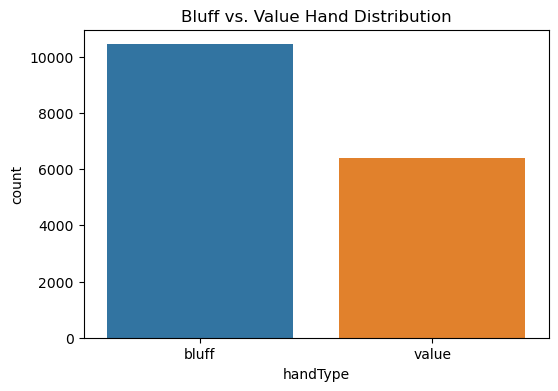

In [2]:
# class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="handType", order=df["handType"].value_counts().index)
plt.title("Bluff vs. Value Hand Distribution")
plt.show()

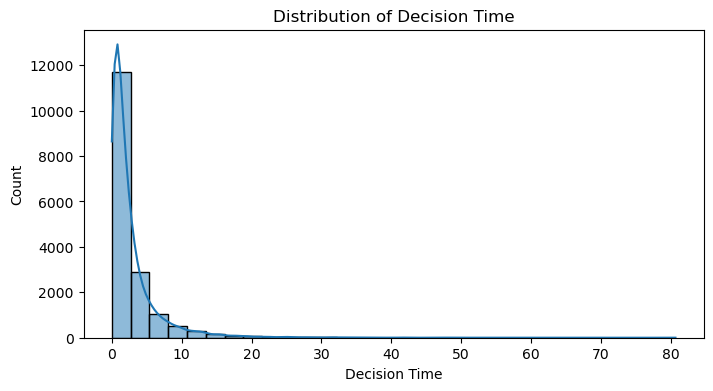

In [3]:
# decision time distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["decision_time"], bins=30, kde=True)
plt.title("Distribution of Decision Time")
plt.xlabel("Decision Time")
plt.show()

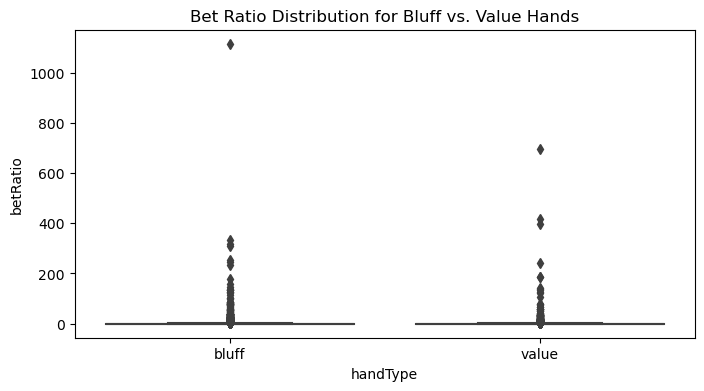

In [4]:
# bet ratio analysis by hand type
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="handType", y="betRatio")
plt.title("Bet Ratio Distribution for Bluff vs. Value Hands")
plt.show()

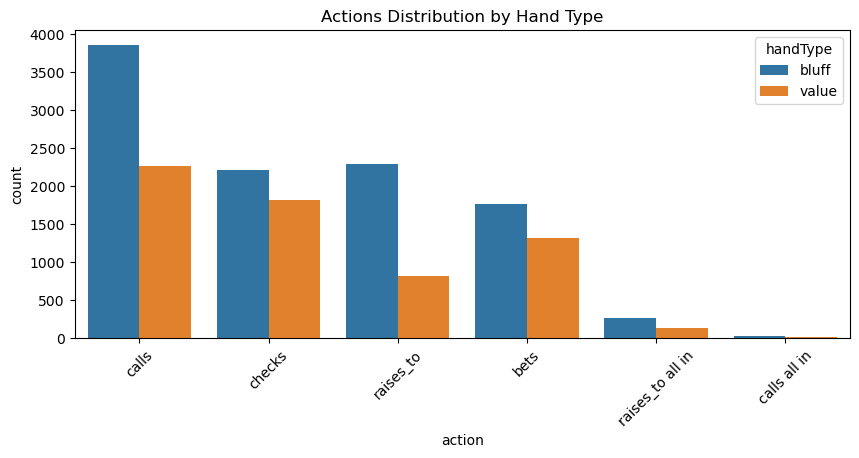

In [5]:
# actions taken analysis
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="action", order=df["action"].value_counts().index, hue="handType")
plt.xticks(rotation=45)
plt.title("Actions Distribution by Hand Type")
plt.show()

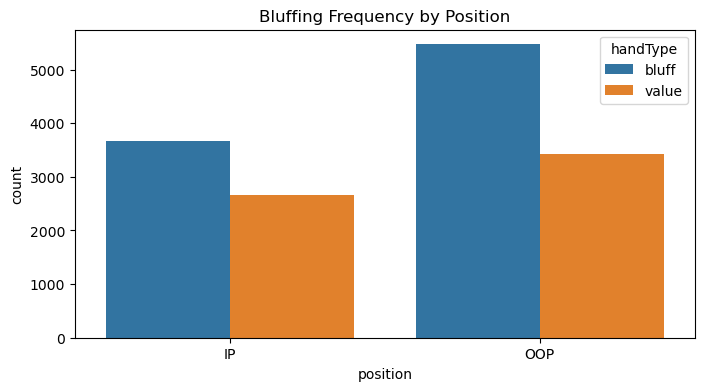

In [6]:
# position impact
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="position", hue="handType")
plt.title("Bluffing Frequency by Position")
plt.show()

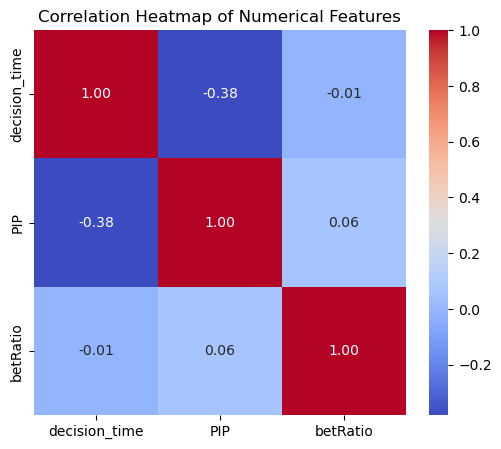

In [7]:
# correlation btwn numerical features
numerical_features = ["decision_time", "PIP", "betRatio"]
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [8]:
# avg time for bluff
bluffs = df[df["handType"] == "bluff"]
bluffs["decision_time"].mean()

2.3381807125071825

In [9]:
# avg time for value
value = df[df["handType"] == "value"]
value["decision_time"].mean()

3.468832915360502